# Plotting Material Properties

This notebook reproduces the main formulas from `MaterialProperties.cpp` and plots them for `c` from `0` to `1.0`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


MATERIAL_DIR = Path("../inputs/materials")

# Faraday constant from your Constants::Frd
FRD = 96485.3365

# Electrolyte diffusivity constant from Constants::D0
D0 = 0.00489

# Concentration range: double c from 0 to 1.0
c = np.linspace(0.0, 1.0, 1001)

# Avoid singular endpoint behavior for functions that clamp c internally
c_safe = np.clip(c, 1.0e-8, 1.0 - 1.0e-8)

plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "axes.grid": True,
    "font.size": 12,
})

## Helper functions

In [2]:
def load_vector(filename, expected_size=None):
    # Load one-column material property table.
    path = MATERIAL_DIR / filename
    if not path.exists():
        print(f"Missing file: {path}")
        return None

    arr = np.loadtxt(path)
    arr = np.asarray(arr, dtype=float)

    if expected_size is not None and len(arr) != expected_size:
        print(f"Warning: {filename} has {len(arr)} values, expected {expected_size}.")

    return arr


def table_values(x, ticks, data):
    # Python version of GetTableValues with endpoint clamping and linear interpolation.
    return np.interp(x, ticks, data, left=data[0], right=data[-1])


def plot_property(x, y, title, ylabel, xlabel="c"):
    fig, ax = plt.subplots()
    ax.plot(x, y)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.show()


def plot_many(x, series, title, ylabel, xlabel="c"):
    fig, ax = plt.subplots()
    for label, y in series.items():
        if y is not None:
            ax.plot(x, y, label=label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.show()

## NMC functions

In [3]:
def nmc_ocv(c):
    return (1.095 * c**2) - (8.234e-7 * np.exp(14.31 * c)) + (4.692 * np.exp(-0.5389 * c))


def nmc_mu(c):
    return -FRD * nmc_ocv(c)


def nmc_i0(c):
    val = -0.2 * (c - 0.37) - 1.559 - 0.9376 * np.tanh(8.961 * c - 3.195)
    return (10.0**val) * 1.0e-3


def nmc_diff(c):
    return (0.0277 - 0.084 * c + 0.1003 * c**2) * 1.0e-8


def nmc_conductivity(c):
    return 0.01929 + 0.7045 * np.tanh(2.399 * c) - 0.7238 * np.tanh(2.412 * c) - 4.2106e-6

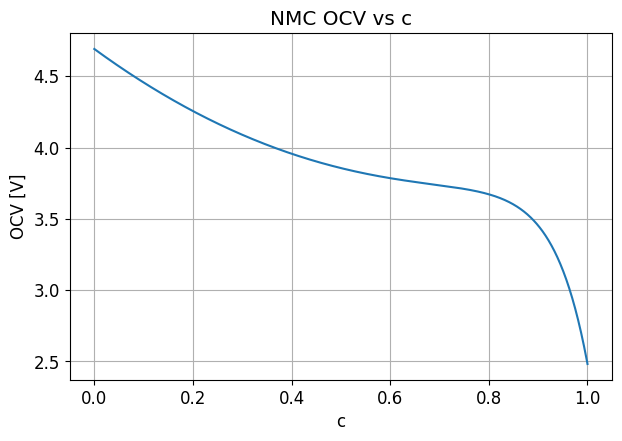

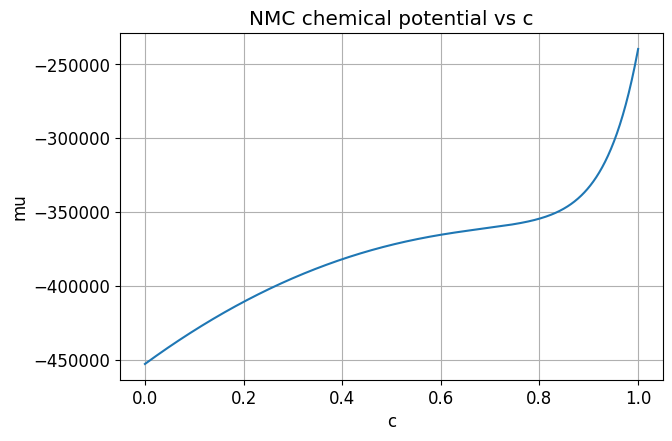

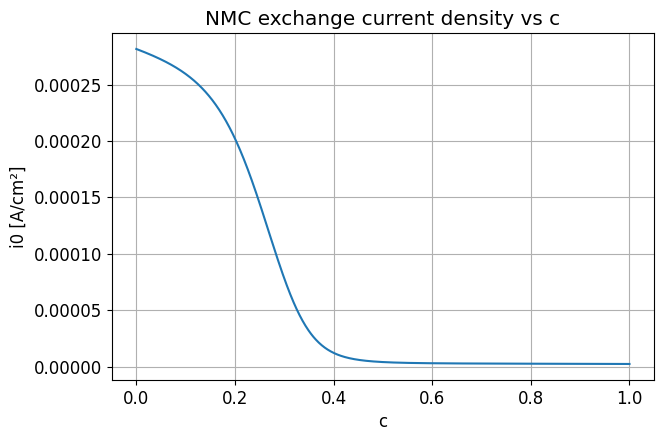

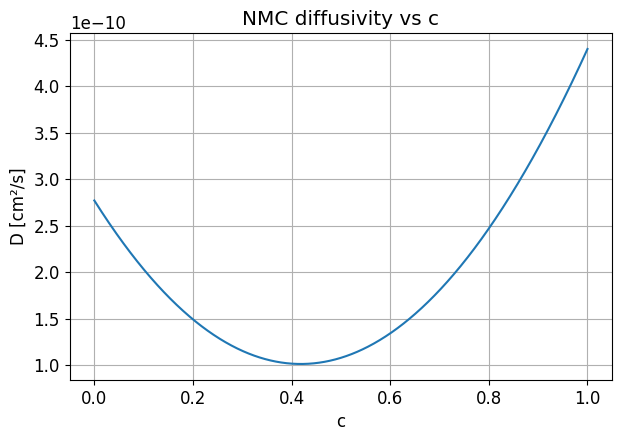

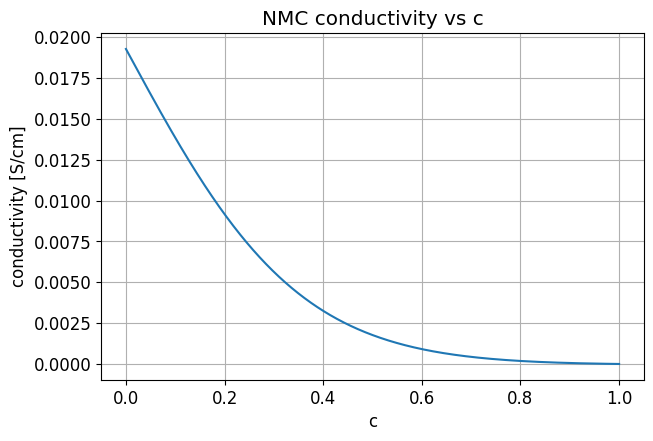

In [4]:
plot_property(c, nmc_ocv(c), "NMC OCV vs c", "OCV [V]")
plot_property(c, nmc_mu(c), "NMC chemical potential vs c", "mu")
plot_property(c, nmc_i0(c), "NMC exchange current density vs c", "i0 [A/cm²]")
plot_property(c, nmc_diff(c), "NMC diffusivity vs c", "D [cm²/s]")
plot_property(c, nmc_conductivity(c), "NMC conductivity vs c", "conductivity [S/cm]")

In [5]:
print(nmc_mu(0.80))
print(nmc_ocv(0.92))

-354333.5456329175
3.354942801510199


## LFP functions


In [6]:
lfp_ticks = load_vector("LFP_Chm_Pot_Ticks.txt", expected_size=201)
lfp_chm_pot = load_vector("LFP_Chm_Pot.txt", expected_size=201)


def lfp_table_value(c):
    if lfp_ticks is None or lfp_chm_pot is None:
        return None
    return table_values(c, lfp_ticks, lfp_chm_pot)
    return ((-1 * table_values(c, lfp_ticks, lfp_chm_pot)) + 3.4) * -96485.3365

#   double val = ((-1 * GetTableValues(c, Ticks, chmPot)) + 3.4) * -Constants::Frd;


# def lfp_ocv(c):
#     chp = lfp_chp_value(c)
#     if chp is None:
#         return None
#     return -chp + 3.4


def lfp_mu(c):
    chp = lfp_table_value(c)
    if chp is None:
        return None
    return ((-1 * table_values(c, lfp_ticks, lfp_chm_pot)) + 3.4) * -96485.3365

    # return chp * 10

def lfp_ocv(c):
    chp = lfp_table_value(c)
    if chp is None:
        return None
    return -chp + 3.4

def lfp_dmu_dc(c):
    # Same finite-difference spacing as your C++ code
    h = 0.005
    c1 = np.maximum(0.0, c - h)
    c2 = np.minimum(1.0, c + h)
    return (lfp_mu(c2) - lfp_mu(c1)) / (c2 - c1)


def lfp_diff(c):
    return np.full_like(c, 5.0e-14, dtype=float)


# def lfp_mob(c):
#     c_clamped = np.clip(c, 1.0e-8, 1.0 - 1.0e-8)
#     D = lfp_diff(c_clamped)
#     dmu = lfp_dmu_dc(c_clamped)
#     return D / np.abs(dmu)

def lfp_mob(c):
    c_clamped = np.clip(c, 1.0e-8, 1.0 - 1.0e-8)
    D = lfp_diff(c_clamped)
    dmu = lfp_dmu_dc(c_clamped)

    M = D / np.abs(dmu)

    return np.minimum(M, 5.85e-13)


def lfp_i0(c):
    c_clamped = np.clip(c, 1.0e-8, 1.0 - 1.0e-8)
    i0_mA = 2.75 * (1.0 - np.exp(-18.0 * c_clamped)) * (1.0 - np.exp(-18.0 * (1.0 - c_clamped)))
    return 4.0 * i0_mA * 1.0e-6


def lfp_conductivity(c):
    return np.full_like(c, 1.0e-4, dtype=float)

def lfp_mob_smooth(c):

    Mmin = 8.5e-13

    B = 5.0e-14

    A1 = 4.5e-12
    A2 = 4.0e-12

    c1 = 0.06
    c2 = 0.86

    w1 = 0.04
    w2 = 0.04

    return (
        Mmin
        + B*(c - 0.5)**2
        + A1/(1.0 + ((c-c1)/w1)**2)
        + A2/(1.0 + ((c-c2)/w2)**2)
    )

# def lfp_mob_smooth(c):
#     M0 = 8.0e-13      # baseline mobility
#     A  = 5.2e-12      # peak height above baseline
#     c1 = 0.07         # left peak location
#     c2 = 0.86         # right peak location
#     sigma = 0.01     # peak width; larger = smoother/wider

#     return (
#         M0
#         + A * np.exp(-((c - c1)**2) / (2 * sigma**2))
#         + A * np.exp(-((c - c2)**2) / (2 * sigma**2))
#     )

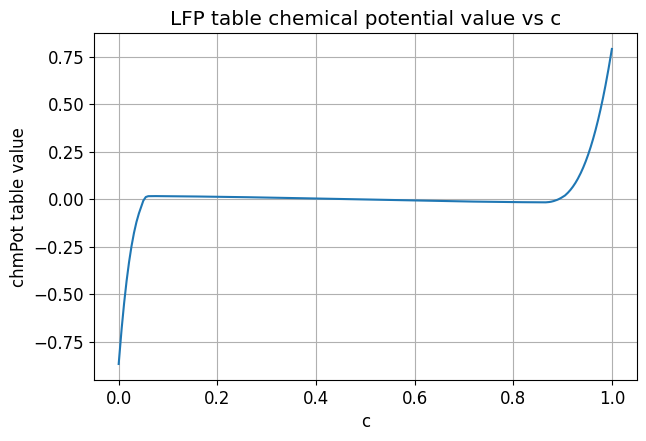

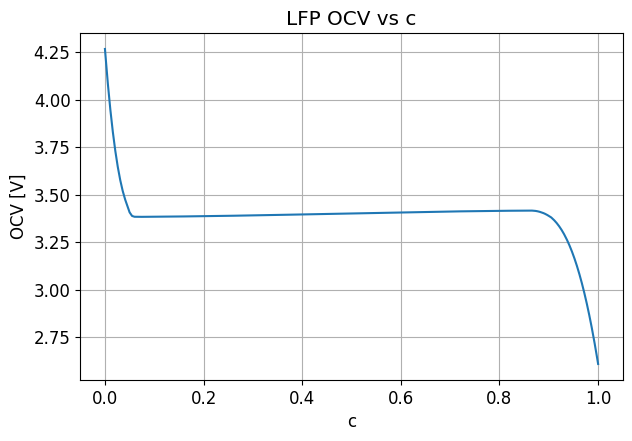

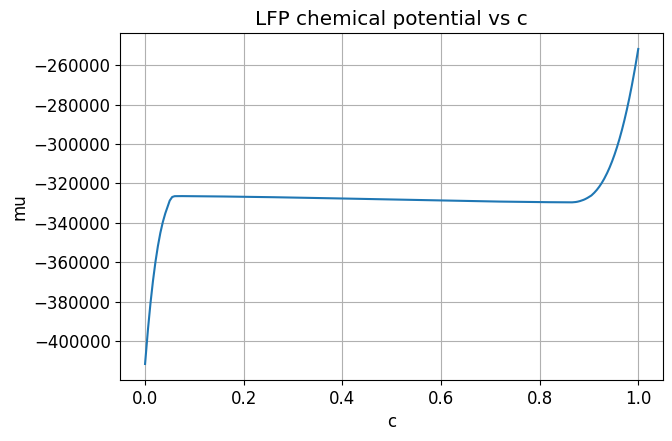

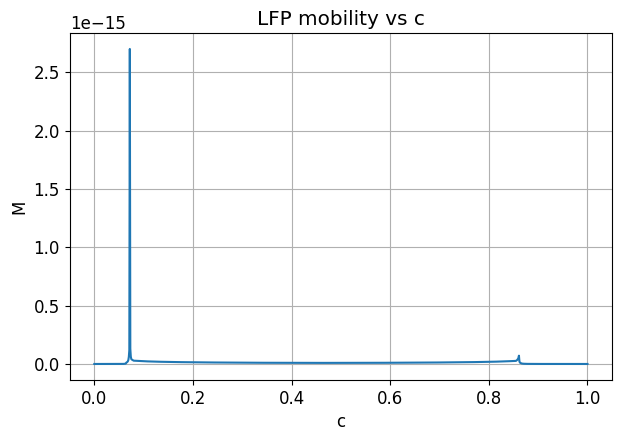

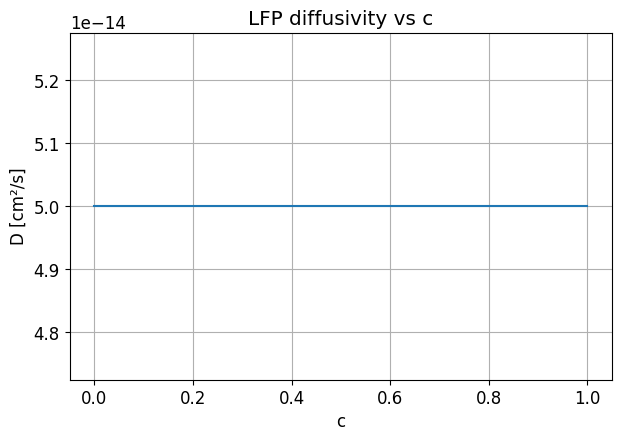

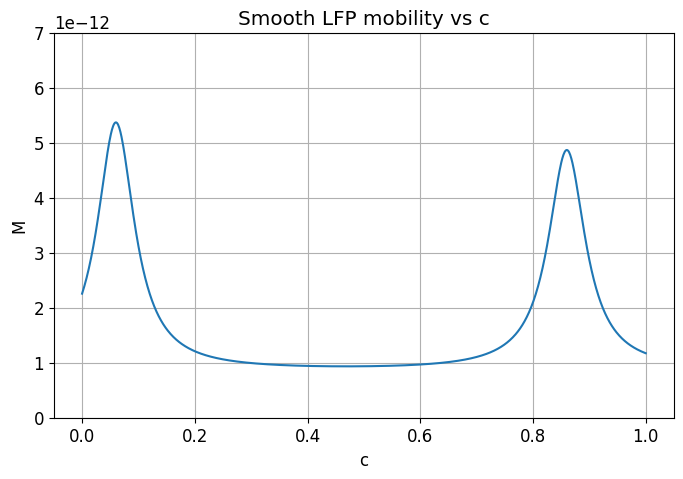

In [7]:
if lfp_ticks is not None and lfp_chm_pot is not None:
    plot_property(c, lfp_table_value(c), "LFP table chemical potential value vs c", "chmPot table value")
    plot_property(c, lfp_ocv(c), "LFP OCV vs c", "OCV [V]")
    plot_property(c, lfp_mu(c), "LFP chemical potential vs c", "mu")
    # plot_property(c, lfp_dmu_dc(c), "LFP dmu/dc vs c", "dmu/dc")
    plot_property(c, lfp_mob(c), "LFP mobility vs c", "M")
    # plt.figure(figsize=(8,5))
    # plt.plot(c, lfp_mob(c))
    # plt.xlabel("c")
    # plt.ylabel("M")
    # plt.title("LFP mobility vs c")
    # plt.grid(True)
    # plt.ylim(0, 7e-12)
    # plt.show()
else:
    print("Skipping LFP table-based plots because the LFP table files were not found.")

# plot_property(c, lfp_i0(c), "LFP exchange current density vs c", "i0 [A/cm²]")
plot_property(c, lfp_diff(c), "LFP diffusivity vs c", "D [cm²/s]")
# plot_property(c, lfp_conductivity(c), "LFP conductivity vs c", "conductivity [S/cm]")


plt.figure(figsize=(8,5))
plt.plot(c, lfp_mob_smooth(c))
plt.xlabel("c")
plt.ylabel("M")
plt.title("Smooth LFP mobility vs c")
plt.ylim(0, 7e-12)
plt.grid(True)
plt.show()

In [10]:
print(lfp_ocv(0.70))
print(lfp_ocv(0.70))

3.4115309
3.4115309


## Graphite functions


In [ ]:
graphite_ticks = load_vector("C_Li_X_101.txt", expected_size=101)
graphite_ocv_table = load_vector("C_Li_O3_101.txt", expected_size=101)
graphite_i0_table = load_vector("C_Li_J2_101.txt", expected_size=101)
graphite_mob_table = load_vector("C_Li_Mb5_101.txt", expected_size=101)
graphite_mu_table = load_vector("C_Li_M6_101.txt", expected_size=101)


def graphite_ocv(c):
    if graphite_ticks is None or graphite_ocv_table is None:
        return None
    return table_values(c, graphite_ticks, graphite_ocv_table)


def graphite_i0(c):
    if graphite_ticks is None or graphite_i0_table is None:
        return None
    return table_values(c, graphite_ticks, graphite_i0_table) * 1.0e-3


def graphite_mob(c):
    if graphite_ticks is None or graphite_mob_table is None:
        return None
    # Same scaling as your C++ code: Mob(i) *= 100.0 * 2.0/3.0
    return table_values(c, graphite_ticks, graphite_mob_table * 100.0 * 2.0 / 3.0)


def graphite_mu(c):
    if graphite_ticks is None or graphite_mu_table is None:
        return None
    return table_values(c, graphite_ticks, graphite_mu_table)


def graphite_conductivity(c):
    return np.full_like(c, 3.3, dtype=float)

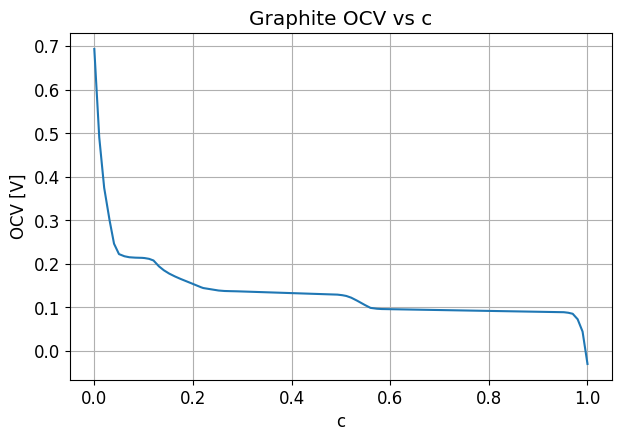

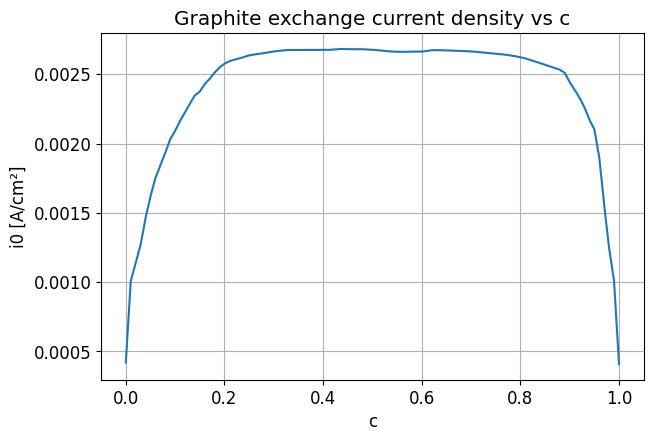

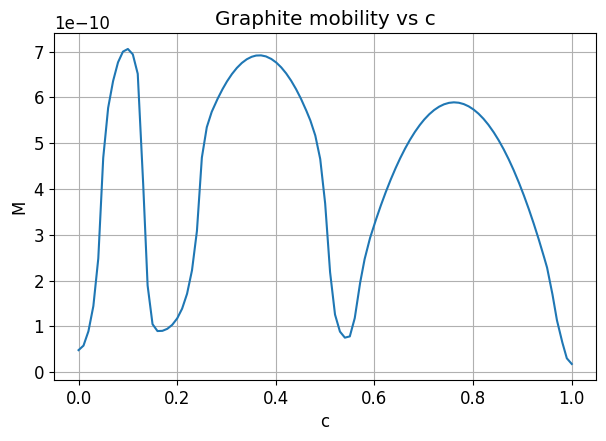

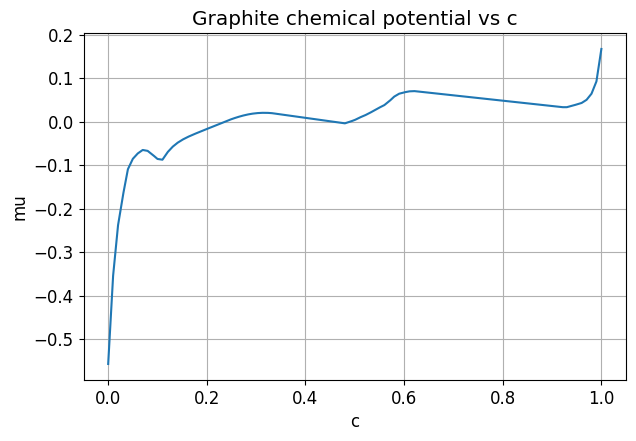

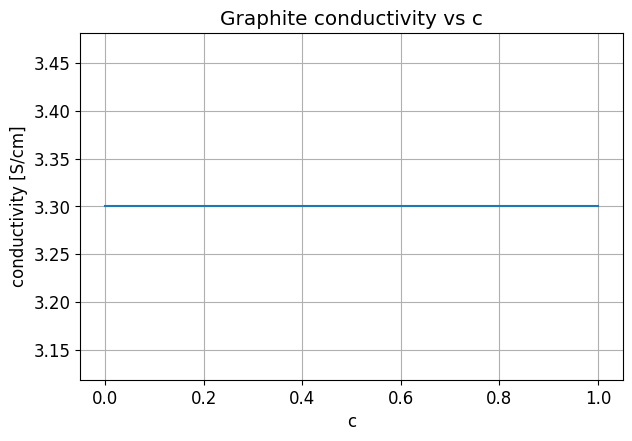

In [ ]:
if graphite_ticks is not None:
    if graphite_ocv_table is not None:
        plot_property(c, graphite_ocv(c), "Graphite OCV vs c", "OCV [V]")
    if graphite_i0_table is not None:
        plot_property(c, graphite_i0(c), "Graphite exchange current density vs c", "i0 [A/cm²]")
    if graphite_mob_table is not None:
        plot_property(c, graphite_mob(c), "Graphite mobility vs c", "M")
    if graphite_mu_table is not None:
        plot_property(c, graphite_mu(c), "Graphite chemical potential vs c", "mu")
else:
    print("Skipping graphite table-based plots because graphite_ticks was not found.")

plot_property(c, graphite_conductivity(c), "Graphite conductivity vs c", "conductivity [S/cm]")

## Compare materials on the same axes

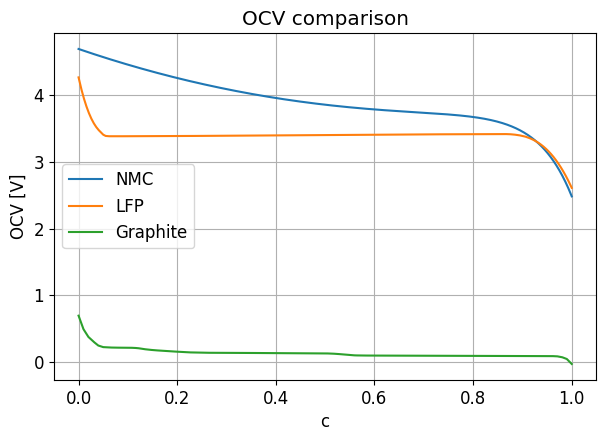

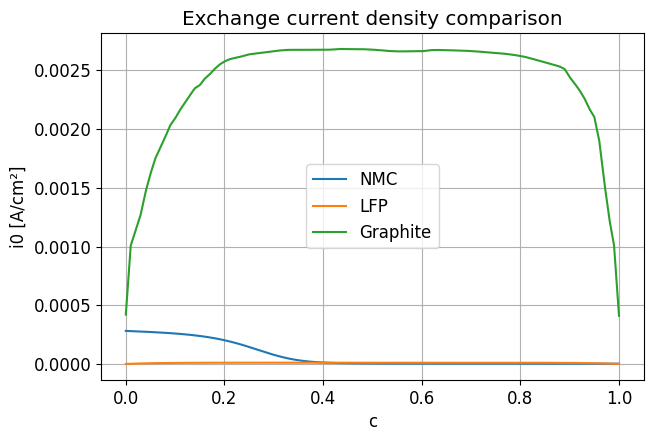

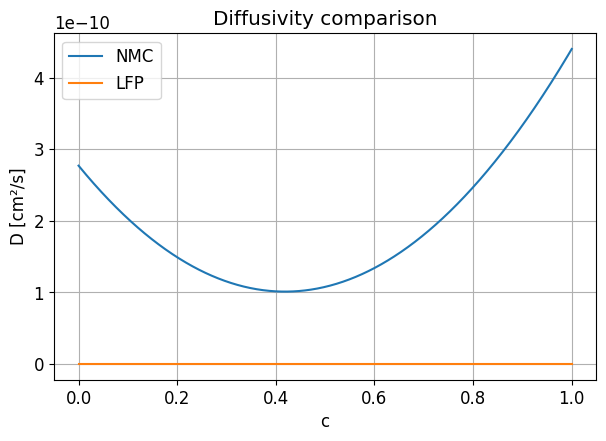

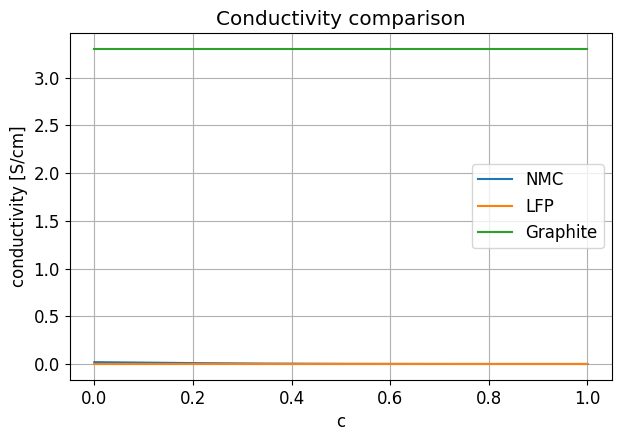

In [ ]:
# OCV comparison
plot_many(
    c,
    {
        "NMC": nmc_ocv(c),
        "LFP": lfp_ocv(c) if lfp_ticks is not None and lfp_chm_pot is not None else None,
        "Graphite": graphite_ocv(c) if graphite_ticks is not None and graphite_ocv_table is not None else None,
    },
    "OCV comparison",
    "OCV [V]",
)

# Exchange current density comparison
plot_many(
    c,
    {
        "NMC": nmc_i0(c),
        "LFP": lfp_i0(c),
        "Graphite": graphite_i0(c) if graphite_ticks is not None and graphite_i0_table is not None else None,
    },
    "Exchange current density comparison",
    "i0 [A/cm²]",
)

# Diffusivity comparison where available
plot_many(
    c,
    {
        "NMC": nmc_diff(c),
        "LFP": lfp_diff(c),
    },
    "Diffusivity comparison",
    "D [cm²/s]",
)

# Conductivity comparison
plot_many(
    c,
    {
        "NMC": nmc_conductivity(c),
        "LFP": lfp_conductivity(c),
        "Graphite": graphite_conductivity(c),
    },
    "Conductivity comparison",
    "conductivity [S/cm]",
)